## Correlation and Redundancy

I claim that there is correlation and redundancy in the `customer` table. What I mean by this is that some features are linear combinations of other features. 

Let's examine redundancy by dropping a feature and seeing if the other features can predict it.

$$\hat{f}(\mathbf{x}) \approx f(\mathbf{x}) + \epsilon$$

Have inputs and outputs and we want to find an approximation to the relationship between them.

From Algebra I, we give students the input and the equation. 

$$f(x) = 2x + 1$$

We give $x$ and ask for $y = f(x)$, if $x = 1$ then $y = 3$.

We give $x$ and ask for $y = f(x)$, if $x = 2$ then $y = 5$.

We give $x$ and ask for $y = f(x)$, if $x = 3$ then $y = 7$.

With supervised learning, we don't have the function we have the data.




In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
import matplotlib.pyplot as plt

%matplotlib inline
from IPython.display import display

customers = pd.read_csv('Wholesale_customers_data.csv')
customers.Region = customers.Region.astype('category')
customers.Channel = customers.Channel.astype('category')
customer_features = customers.select_dtypes(exclude = ['category'])

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor # may be interesting that tree-based model is non-linear

In [5]:
customer_features.columns

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper',
       'Delicatessen'],
      dtype='object')

In [4]:
customer_features['Detergents_Paper'].shape

(440,)

In [6]:
train_test_split?

Signature:
train_test_split(
    *arrays,
    test_size=None,
    train_size=None,
    random_state=None,
    shuffle=True,
    stratify=None,
)
Docstring:
Split arrays or matrices into random train and test subsets.

Quick utility that wraps input validation,
``next(ShuffleSplit().split(X, y))``, and application to input data
into a single call for splitting (and optionally subsampling) data into a
one-liner.

Read more in the :ref:`User Guide <cross_validation>`.

Parameters
----------
*arrays : sequence of indexables with same length / shape[0]
    Allowed inputs are lists, numpy arrays, scipy-sparse
    matrices or pandas dataframes.

test_size : float or int, default=None
    If float, should be between 0.0 and 1.0 and represent the proportion
    of the dataset to include in the test split. If int, represents the
    absolute number of test samples. If None, the value is set to the
    complement of the train size. If ``train_size`` is also None, it will
    be set to 0.25.

trai

In [7]:
def calculate_r_2_for_feature(data, feature):
    new_data = data.drop(feature, axis=1)
    target = data[feature]

    X_train, \
    X_test,  \
    y_train, \
    y_test = train_test_split(
        new_data,target,test_size=0.25
    )

    regressor = DecisionTreeRegressor()
    regressor.fit(X_train,y_train)

    score = regressor.score(X_test,y_test)
    return score

In [16]:

new_data = customer_features.drop('Detergents_Paper', axis=1)
target = customer_features['Detergents_Paper']
X_train_1, \
X_test_1,  \
y_train_1, \
y_test_1 = train_test_split(new_data, target,test_size=0.25)
X_train_2, \
X_test_2,  \
y_train_2, \
y_test_2 = train_test_split(new_data, target,test_size=0.25)

In [19]:
X_train_1.index.tolist()[:20]

[35,
 327,
 32,
 408,
 33,
 214,
 297,
 110,
 370,
 2,
 152,
 166,
 25,
 245,
 213,
 417,
 283,
 217,
 160,
 268]

In [20]:
X_train_2.index.tolist()[:20]

[401,
 7,
 263,
 284,
 320,
 383,
 64,
 325,
 327,
 426,
 386,
 137,
 302,
 384,
 168,
 315,
 74,
 420,
 57,
 50]

In [8]:
calculate_r_2_for_feature(customer_features,'Detergents_Paper')

0.49270666075690994

In [13]:
print("{:24} {}".format("Delicatessen: ", calculate_r_2_for_feature(customer_features,'Delicatessen')))
print("{:24} {}".format("Detergents_paper: ", calculate_r_2_for_feature(customer_features,'Detergents_Paper')))
print("{:24} {}".format("Fresh: ", calculate_r_2_for_feature(customer_features,'Fresh')))
print("{:24} {}".format("Frozen: ", calculate_r_2_for_feature(customer_features,'Frozen')))
print("{:24} {}".format("Grocery: ", calculate_r_2_for_feature(customer_features,'Grocery')))
print("{:24} {}".format("Milk: ", calculate_r_2_for_feature(customer_features,'Milk')))

Delicatessen:            -0.7539027808730108
Detergents_paper:        0.6654365348990684
Fresh:                   -1.2746163731311828
Frozen:                  -0.8287009315527727
Grocery:                 0.6717840355553016
Milk:                    0.0438891103133503


But this is subject to randomness. There is randomness in my `train_test_split`. Let's do the whole thing many times and take the average. 

In [24]:
def mean_r2_for_feature(data, feature, n_trials=100):
    scores = []
    for _ in range(n_trials):
        scores.append(calculate_r_2_for_feature(data, feature))
        
    scores = np.array(scores)
    return scores.mean()

In [25]:
print("{:24} {}".format("Delicatessen: ", mean_r2_for_feature(customer_features,'Delicatessen', 1000)))
print("{:24} {}".format("Detergents_Paper: ", mean_r2_for_feature(customer_features,'Detergents_Paper', 1000)))
print("{:24} {}".format("Fresh: ", mean_r2_for_feature(customer_features,'Fresh', 1000)))
print("{:24} {}".format("Frozen: ", mean_r2_for_feature(customer_features,'Frozen', 1000)))
print("{:24} {}".format("Grocery: ", mean_r2_for_feature(customer_features,'Grocery', 1000)))
print("{:24} {}".format("Milk: ", mean_r2_for_feature(customer_features,'Milk', 1000)))

Delicatessen:            -3.0201604450924298
Detergents_Paper:        0.6775546457843982
Fresh:                   -0.7415686540836612
Frozen:                  -1.1655153142533545
Grocery:                 0.6701099522046955
Milk:                    0.1305290817700479


In [26]:
print("{:24} {}".format("Delicatessen: ", mean_r2_for_feature(customer_features,'Delicatessen', 1000)))
print("{:24} {}".format("Detergents_Paper: ", mean_r2_for_feature(customer_features,'Detergents_Paper', 1000)))
print("{:24} {}".format("Fresh: ", mean_r2_for_feature(customer_features,'Fresh', 1000)))
print("{:24} {}".format("Frozen: ", mean_r2_for_feature(customer_features,'Frozen', 1000)))
print("{:24} {}".format("Grocery: ", mean_r2_for_feature(customer_features,'Grocery', 1000)))
print("{:24} {}".format("Milk: ", mean_r2_for_feature(customer_features,'Milk', 1000)))

Delicatessen:            -3.0190934334057076
Detergents_Paper:        0.671448677842584
Fresh:                   -0.7527103622443104
Frozen:                  -1.2052056151266366
Grocery:                 0.6763259011691902
Milk:                    0.12933809809417215


##### Discussion

What does this tell us?

### Visualize Redundancy

Study the correlation of the data.

1.8780527114868164


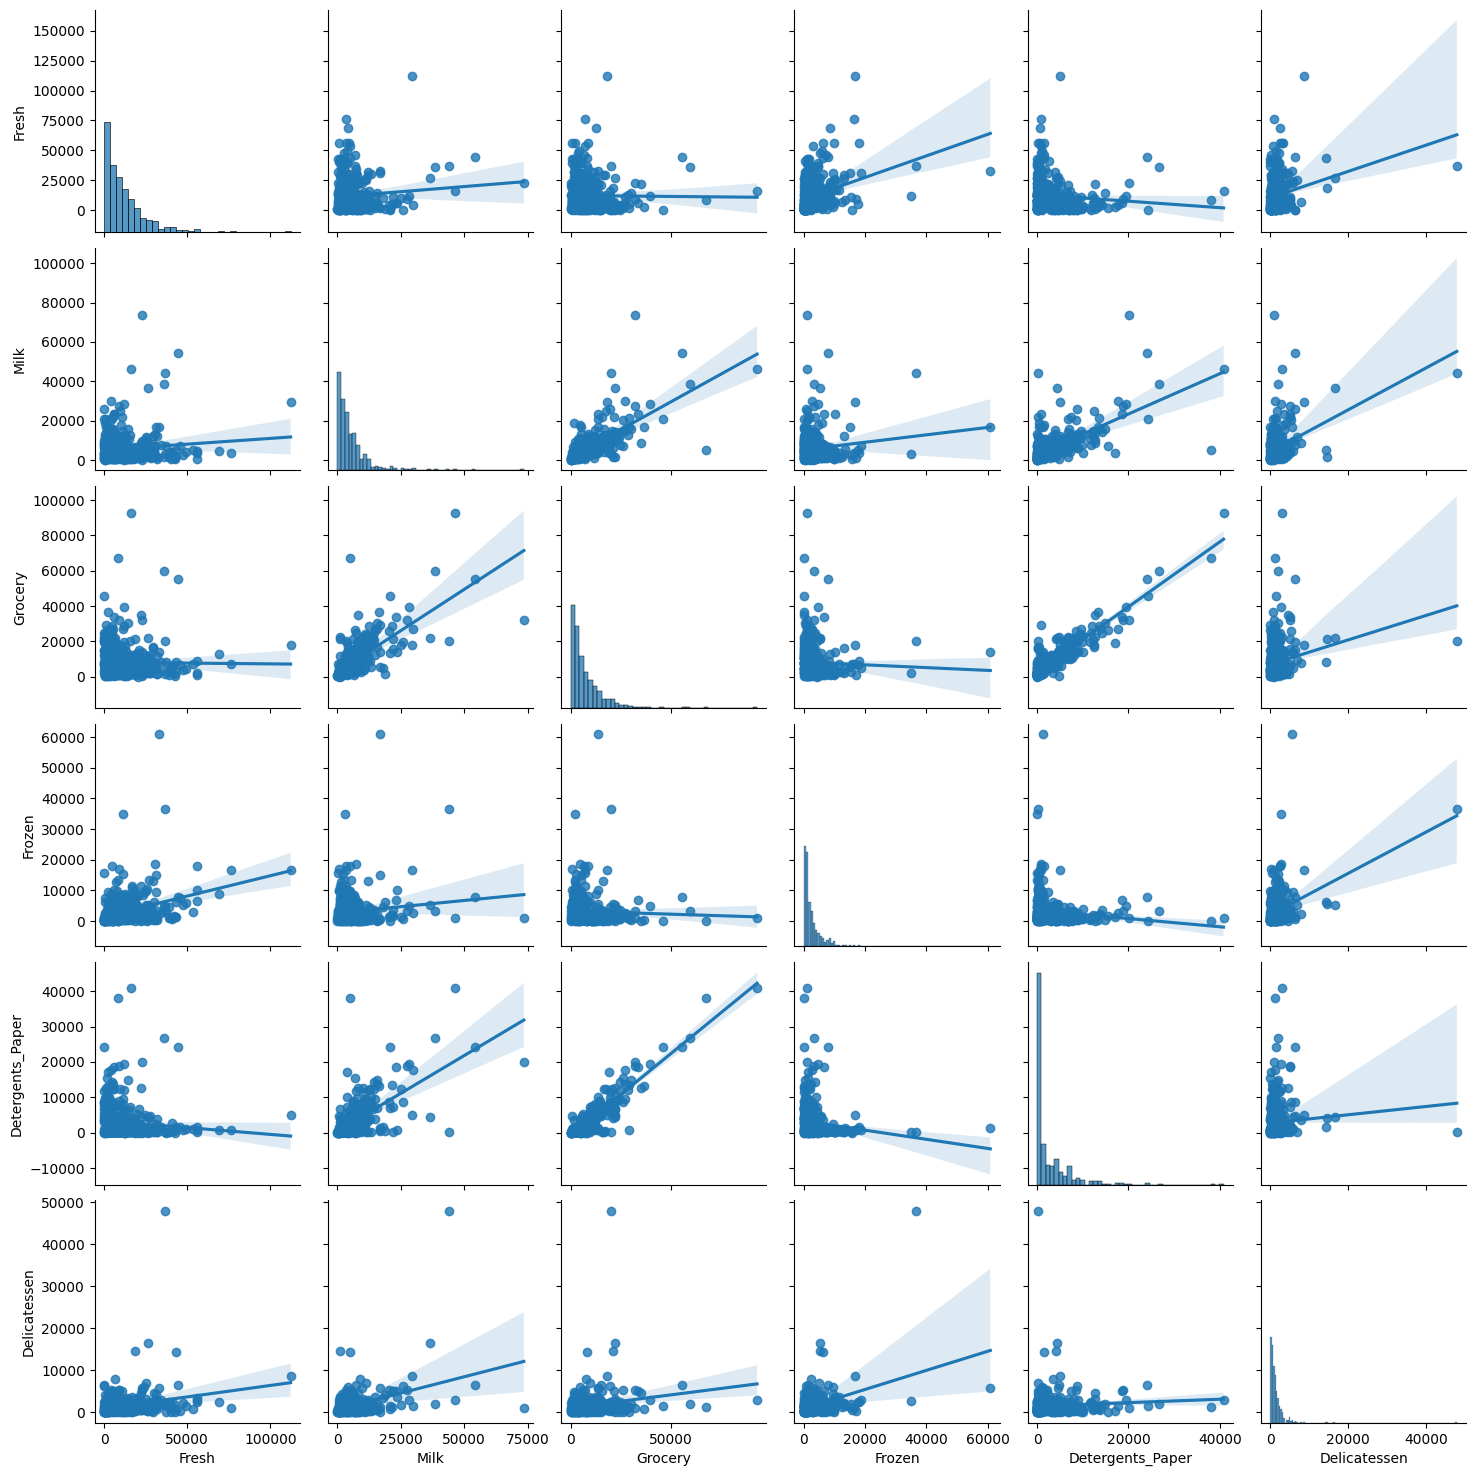

In [27]:
import time
start = time.time()
sns.pairplot(customer_features, kind='reg')
print(time.time() - start)

In [28]:
# tree-based models are information-based, a tree is formed by looking at the information gain of each feature
customer_features.corr() # linear relationship


,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
Fresh,1.000000,0.100510,-0.011854,0.345881,-0.101953,0.244690
Milk,0.100510,1.000000,0.728335,0.123994,0.661816,0.406368
Grocery,-0.011854,0.728335,1.000000,-0.040193,0.924641,0.205497
Frozen,0.345881,0.123994,-0.040193,1.000000,-0.131525,0.390947
Detergents_Paper,-0.101953,0.661816,0.924641,-0.131525,1.000000,0.069291
Delicatessen,0.244690,0.406368,0.205497,0.390947,0.069291,1.000000


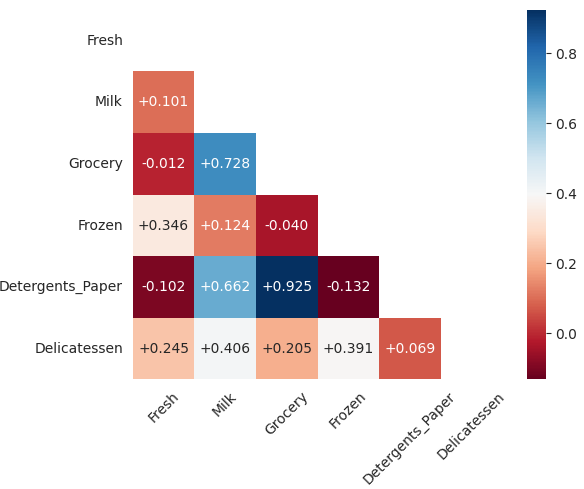

In [29]:
corr = customer_features.corr()
mask = np.zeros_like(corr)
mask[np.triu_indices_from(mask, 0)] = True
with sns.axes_style("white"):
    ax = sns.heatmap(corr, mask=mask, square=True, annot=True,
                     cmap='RdBu', fmt='+.3f')
    plt.xticks(rotation=45, ha='center')

In [30]:
from sklearn.preprocessing import StandardScaler
import scipy.stats as st

In [31]:
sample_1pct_1 = customer_features.sample(5)

In [32]:
samp_stats = sample_1pct_1.describe().T
samp_stats['skew'] = st.skew(sample_1pct_1)
samp_stats['kurt'] = st.kurtosis(sample_1pct_1)
samp_stats

,count,mean,std,min,25%,50%,75%,max,skew,kurt
Fresh,5.0,9663.6,11736.876130,97.0,2790.0,6006.0,9790.0,29635.0,1.161131,-0.202524
Milk,5.0,4269.2,3871.307299,1786.0,2335.0,2527.0,3605.0,11093.0,1.395225,0.102110
Grocery,5.0,9987.0,5786.445844,5109.0,5265.0,8280.0,12400.0,18881.0,0.708715,-0.947600
Frozen,5.0,2697.0,2150.662689,98.0,1159.0,3046.0,3570.0,5612.0,0.120358,-1.188424
Detergents_Paper,5.0,2347.2,3049.446458,182.0,371.0,788.0,2970.0,7425.0,1.079397,-0.441028
Delicatessen,5.0,936.0,862.569707,62.0,117.0,1043.0,1360.0,2098.0,0.187037,-1.369104


In [33]:
stats = customer_features.describe().T
stats['skew'] = st.skew(customer_features)
stats['kurt'] = st.kurtosis(customer_features)
stats

,count,mean,std,min,25%,50%,75%,max,skew,kurt
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0,2.552583,11.392124
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0,4.039922,24.376349
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0,3.575187,20.664153
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0,5.887826,54.056180
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0,3.619458,18.780528
Delicatessen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0,11.113534,168.747781


---

In [34]:
customer_z_scores = (customer_features - customer_features.mean())/customer_features.std()

#### MANY OF THE TOOLS WE WILL USE WILL ASSUME NORMAL DATA

---

You are already familiar with standardization.

$$Z = \frac{X-\mu}{\sigma}$$

In [35]:
customer_z_scores = (customer_features - customer_features.mean())/customer_features.std()

Instantiate the scaler.

In [36]:
scaler = StandardScaler()

In [38]:
customer_scaled = scaler.fit_transform(customer_features)

In [39]:
scaler.fit(customer_features)
customer_sc = scaler.transform(customer_features)

Load it into a dataframe.

In [40]:
customer_sc_df = pd.DataFrame(customer_sc, columns=customer_features.columns)

In [41]:
customer_z_scores.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,0.052873,0.522972,-0.041068,-0.588697,-0.043519,-0.066264
1,-0.390857,0.543839,0.170125,-0.269829,0.086309,0.089050
2,-0.446521,0.408073,-0.028125,-0.137379,0.133080,2.240742
3,0.099998,-0.623310,-0.392530,0.686363,-0.498021,0.093305
4,0.839284,-0.052337,-0.079266,0.173661,-0.231654,1.297870


In [42]:
customer_sc_df.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,0.052933,0.523568,-0.041115,-0.589367,-0.043569,-0.066339
1,-0.391302,0.544458,0.170318,-0.270136,0.086407,0.089151
2,-0.447029,0.408538,-0.028157,-0.137536,0.133232,2.243293
3,0.100111,-0.624020,-0.392977,0.687144,-0.498588,0.093411
4,0.840239,-0.052396,-0.079356,0.173859,-0.231918,1.299347


In [43]:
sc_stats = customer_sc_df.describe().T
sc_stats['skew'] = st.skew(customer_features)
sc_stats['kurt'] = st.kurtosis(customer_features)
display(stats)
display(sc_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurt
Fresh,440.0,12000.297727,12647.328865,3.0,3127.75,8504.0,16933.75,112151.0,2.552583,11.392124
Milk,440.0,5796.265909,7380.377175,55.0,1533.00,3627.0,7190.25,73498.0,4.039922,24.376349
Grocery,440.0,7951.277273,9503.162829,3.0,2153.00,4755.5,10655.75,92780.0,3.575187,20.664153
Frozen,440.0,3071.931818,4854.673333,25.0,742.25,1526.0,3554.25,60869.0,5.887826,54.056180
Detergents_Paper,440.0,2881.493182,4767.854448,3.0,256.75,816.5,3922.00,40827.0,3.619458,18.780528
Delicatessen,440.0,1524.870455,2820.105937,3.0,408.25,965.5,1820.25,47943.0,11.113534,168.747781


,count,mean,std,min,25%,50%,75%,max,skew,kurt
Fresh,440.0,-3.431598e-17,1.001138,-0.949683,-0.702334,-0.276760,0.390523,7.927738,2.552583,11.392124
Milk,440.0,0.000000e+00,1.001138,-0.778795,-0.578306,-0.294258,0.189092,9.183650,4.039922,24.376349
Grocery,440.0,-4.037175e-17,1.001138,-0.837334,-0.610836,-0.336668,0.284911,8.936528,3.575187,20.664153
Frozen,440.0,3.633457e-17,1.001138,-0.628343,-0.480431,-0.318804,0.099464,11.919002,5.887826,54.056180
Detergents_Paper,440.0,2.422305e-17,1.001138,-0.604416,-0.551135,-0.433600,0.218482,7.967672,3.619458,18.780528
Delicatessen,440.0,-8.074349e-18,1.001138,-0.540264,-0.396401,-0.198577,0.104860,16.478447,11.113534,168.747781


### Visualizing Data Transformation

In [44]:
import warnings

warnings.simplefilter("ignore")

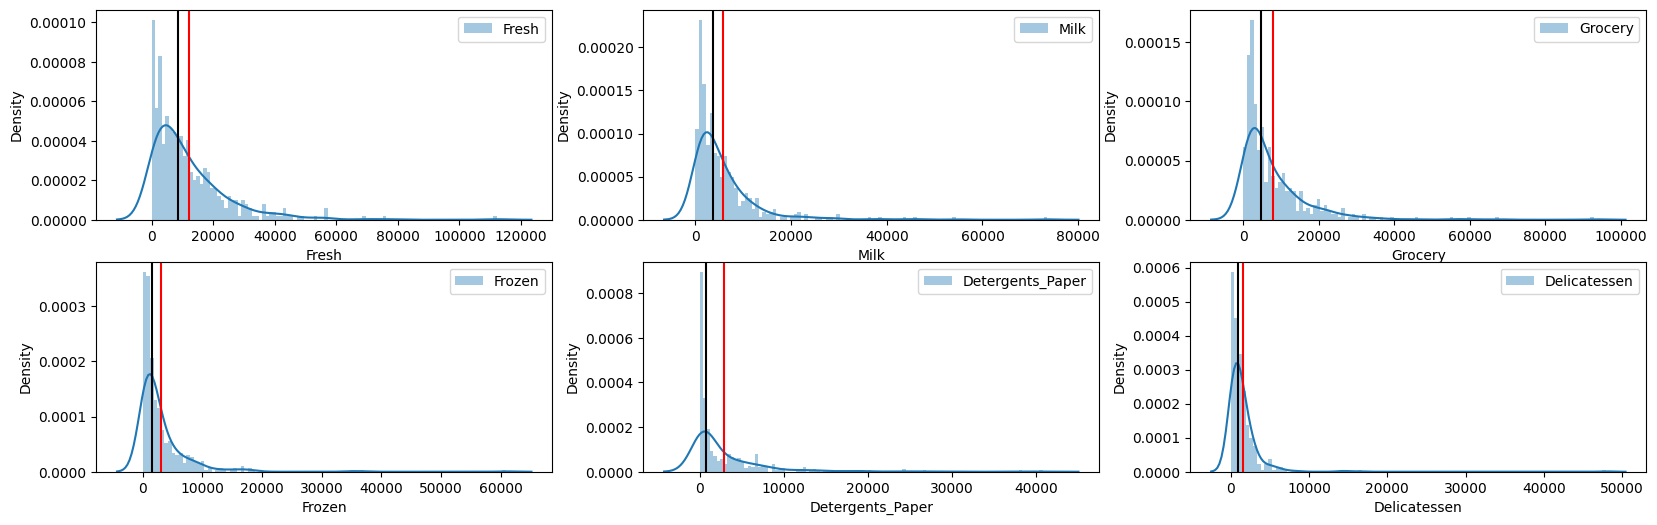

In [45]:
fig = plt.figure(figsize=(20,6))
for i, col in enumerate(customer_features.columns):
    fig.add_subplot(231+i)
    sns.distplot(customer_features[col], label=col, bins=100)
    plt.axvline(customer_features[col].mean(), c='red')
    plt.axvline(customer_features[col].median(), c='black')
    plt.legend()

In [ ]:
fig = plt.figure(figsize=(20,6))
for i, col in enumerate(customer_sc_df.columns):
    fig.add_subplot(231+i)
    sns.distplot(customer_sc_df[col], label=col, bins=100)
    plt.axvline(customer_sc_df[col].mean(), c='red')
    plt.axvline(customer_sc_df[col].median(), c='black')
    plt.legend()
    plt.xlim(-5,15)

#### MANY OF THE TOOLS WE WILL USE WILL ASSUME NORMAL DATA

---